In [8]:
import pandas as pd
import numpy as np
import cv2

# -------------------------
# Paths – AJUSTAR si cambian los nombres
# -------------------------
TRACKS_CSV = "video01/vehicle_tracks_yolo_with_id.csv"
GT_XML     = "video01/vehicles_with_speed.xml"
LANES_XML  = "lanes.xml"
VIDEO_PATH = "video01/video.mp4"

FPS_NOMINAL = 25.0  # fallback

# -------------------------
# Cargar tracks YOLO
# -------------------------
df_tracks = pd.read_csv(TRACKS_CSV)
print("Tracks cargados:", df_tracks.shape)

# bottom-center de cada bbox
df_tracks["px"] = (df_tracks["x1"] + df_tracks["x2"]) / 2
df_tracks["py"] = df_tracks["y2"]

df_tracks["vehicle_id"] = df_tracks["vehicle_id"].astype("Int64")
df_tracks["lane"] = df_tracks["lane"].astype("Int64")

display(df_tracks.head())


# -------------------------
# Cargar ground truth del radar
# -------------------------
import xml.etree.ElementTree as ET

def load_ground_truth_from_xml(xml_path):
    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    rows = []
    for v in root.findall(".//vehicle"):
        vid = v.get("vehicle_id")
        radar = v.find("radar")
        if radar is None:
            continue
        speed = radar.get("speed")
        if speed is None:
            continue

        rows.append({
            "vehicle_id": int(vid),
            "gt_speed": float(speed),
            "lane": int(v.get("lane")) if v.get("lane") is not None else None,
        })

    return pd.DataFrame(rows)

df_gt = load_ground_truth_from_xml(GT_XML)
print("GT cargado:", df_gt.shape)
display(df_gt.head())


# -------------------------
# Cargar homografías desde lanes.xml
# -------------------------
def parse_lanes_xml(xml_path):
    import xml.etree.ElementTree as ET

    REAL_WIDTH = 2.0   # m
    REAL_LENGTH = 4.8  # m

    real_world_points = np.array([
        [0, 0],
        [REAL_WIDTH, 0],
        [0, REAL_LENGTH],
        [REAL_WIDTH, REAL_LENGTH]
    ], dtype=np.float32)

    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    lane_configs = {}
    for measure in root.findall(".//measure"):
        lane_id = int(measure.get("id"))
        pts = []
        for tag in ["pTopLeft", "pTopRight", "pBotLeft", "pBotRight"]:
            node = measure.find(tag)
            x = float(node.get("x"))
            y = float(node.get("y"))
            pts.append([x, y])
        dst = np.array(pts, dtype=np.float32)

        H, _ = cv2.findHomography(dst, real_world_points)

        y_min = dst[:, 1].min()
        y_max = dst[:, 1].max()

        lane_configs[lane_id] = {
            "H": H,
            "trap_limits": {"y_min": y_min, "y_max": y_max},
        }
    return lane_configs

lane_configs = parse_lanes_xml(LANES_XML)
print("Lanes cargados:", lane_configs.keys())


# -------------------------
# Cargar FPS real del video
# -------------------------
def get_video_fps(path):
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if fps > 0:
        print(f"FPS leído del video: {fps}")
        return fps
    print("FPS inválido, usando nominal =", FPS_NOMINAL)
    return FPS_NOMINAL

fps_video = get_video_fps(VIDEO_PATH)


Tracks cargados: (14100, 17)


,video_id,frame,track_id,class_id,class_name,conf,x1,y1,x2,y2,img_w,img_h,fps,center_x,center_y,vehicle_id,lane,px,py
0,video,0,1,2,car,0.422626,334.997620,0.0,549.908020,53.978405,1920,1080,25.0,442.452820,26.989202,<NA>,<NA>,442.452820,53.978405
1,video,0,2,7,truck,0.377719,1058.240112,0.0,1343.984985,93.138657,1920,1080,25.0,1201.112549,46.569328,<NA>,<NA>,1201.112549,93.138657
2,video,1,1,2,car,0.523622,359.220612,0.0,535.078064,43.986061,1920,1080,25.0,447.149338,21.993031,<NA>,<NA>,447.149338,43.986061
3,video,1,2,7,truck,0.518423,1077.124634,0.0,1305.382446,74.068459,1920,1080,25.0,1191.253540,37.034229,<NA>,<NA>,1191.253540,74.068459
4,video,2,2,7,truck,0.352585,1087.623535,0.0,1269.353271,58.196693,1920,1080,25.0,1178.488403,29.098347,<NA>,<NA>,1178.488403,58.196693


GT cargado: (110, 3)


,vehicle_id,gt_speed,lane
0,1,56.65,3
1,2,53.74,3
2,3,52.13,2
3,4,49.06,3
4,5,50.51,2


Lanes cargados: dict_keys([1, 2, 3])
FPS inválido, usando nominal = 25.0


In [9]:
import numpy as np

def pixel_to_world(H, u, v):
    """
    Convierte un punto en píxeles al plano de mundo usando la homografía H.

    Parámetros:
      - H: Matriz 3x3 de homografía.
      - u, v: Coordenadas en píxeles.

    Returns:
      - (x, y): Coordenadas en metros en el plano de la ruta.
    """
    p = np.array([u, v, 1.0], dtype=np.float32)
    w = H @ p
    w /= w[2]
    return float(w[0]), float(w[1])


def compute_speed_trap_regression(df_tracks, lane_configs, fps,
                                  margin_px=10, min_frames=5, use_axis="y"):
    """
    Calcula la velocidad de cada vehículo usando regresión s(t) dentro de la speed trap.

    Pasos:
      - Filtra frames donde el bottom del bbox está dentro de [y_min - margin, y_max + margin].
      - Proyecta cada punto (px, py) a mundo con H del carril.
      - Usa la coord 'y' como posición s(t) (eje de avance del auto).
      - Ajusta una recta s(t) = a * t + b y toma |a| como velocidad (m/s).

    Parámetros:
      - df_tracks: DataFrame con los tracks de YOLO (frame, px, py, vehicle_id, lane).
      - lane_configs: dict con homografía y trap_limits por carril.
      - fps: FPS del video.
      - margin_px: margen en píxeles extra alrededor de la trap.
      - min_frames: mínimo de frames dentro de la trap para estimar velocidad.
      - use_axis: 'y', 'x' o 'norm' para elegir la coordenada de posición.

    Returns:
      - DataFrame con columnas: vehicle_id, lane, speed_trap_reg, dist_m, delta_frames, n_points.
    """
    rows = []
    df_valid = df_tracks.dropna(subset=["vehicle_id"]).copy()
    df_valid["vehicle_id"] = df_valid["vehicle_id"].astype(int)

    for vid, df_v in df_valid.groupby("vehicle_id"):
        lane = df_v["lane"].iloc[0] if "lane" in df_v.columns else None
        if lane not in lane_configs:
            continue

        cfg = lane_configs[lane]
        H = cfg["H"]
        y_min = cfg["trap_limits"]["y_min"] - margin_px
        y_max = cfg["trap_limits"]["y_max"] + margin_px

        # Solo frames donde el bbox está dentro de la speed trap
        df_zone = df_v[(df_v["py"] >= y_min) & (df_v["py"] <= y_max)].sort_values("frame")
        if len(df_zone) < min_frames:
            continue

        # Tiempo en segundos
        t = df_zone["frame"].to_numpy() / fps

        xs, ys = [], []
        for _, row in df_zone.iterrows():
            xw, yw = pixel_to_world(H, row["px"], row["py"])
            xs.append(xw)
            ys.append(yw)
        xs = np.array(xs)
        ys = np.array(ys)

        if use_axis == "y":
            s = ys
        elif use_axis == "x":
            s = xs
        else:  # 'norm'
            s = np.sqrt(xs**2 + ys**2)

        if len(t) < 2 or np.allclose(t, t[0]):
            continue

        # Ajuste lineal s(t) = a * t + b
        a, b = np.polyfit(t, s, 1)  # a en m/s

        # IMPORTANTE: tomamos el módulo de la pendiente (la velocidad no puede ser negativa)
        speed_mps = abs(a)
        speed_kmh = speed_mps * 3.6

        dist_m = s[-1] - s[0]
        delta_frames = df_zone["frame"].iloc[-1] - df_zone["frame"].iloc[0]

        rows.append({
            "vehicle_id": vid,
            "lane": lane,
            "speed_trap_reg": speed_kmh,
            "dist_m": float(dist_m),
            "delta_frames": int(delta_frames),
            "n_points": len(df_zone),
        })

    df_reg = pd.DataFrame(rows)
    print(f"Trap+Regresión: vehículos con velocidad estimada: {df_reg.shape[0]}")
    return df_reg



In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_predictions(df, pred_col="pred_speed", gt_col="gt_speed", verbose=True):
    """
    Calcula MAE, RMSE, MAPE y R^2 para una columna de predicción vs ground truth.

    Parámetros:
      - df: DataFrame con columnas de verdad y predicción.
      - pred_col: nombre de la columna con las velocidades estimadas.
      - gt_col: nombre de la columna con las velocidades reales.

    Returns:
      - dict con las métricas calculadas.
    """
    y_true = df[gt_col].to_numpy()
    y_pred = df[pred_col].to_numpy()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)   # sklearn viejo: no acepta squared=False
    rmse = math.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE_%": mape, "R2": r2}
    if verbose:
        print(f"MAE  = {mae:.2f} km/h")
        print(f"RMSE = {rmse:.2f} km/h")
        print(f"MAPE = {mape:.1f} %")
        print(f"R²   = {r2:.3f}")
    return metrics


def scatter_real_vs_est(df, pred_col="pred_speed", gt_col="gt_speed",
                        title="Real vs Estimado", subtitle=""):
    """
    Grafica velocidades reales vs estimadas con la recta ideal y = x.
    """
    plt.figure(figsize=(6, 5))
    plt.scatter(df[gt_col], df[pred_col], alpha=0.7)
    min_v = min(df[gt_col].min(), df[pred_col].min()) * 0.9
    max_v = max(df[gt_col].max(), df[pred_col].max()) * 1.1
    plt.plot([min_v, max_v], [min_v, max_v], "r--", label="Ideal (y = x)")
    plt.xlabel("Velocidad Real (Radar) [km/h]")
    plt.ylabel("Velocidad Estimada [km/h]")
    plt.title(f"{title}\n{subtitle}")
    plt.legend()
    plt.grid(True)
    plt.show()


Trap+Regresión: vehículos con velocidad estimada: 91
Vehículos con predicción y radar: 91
MAE  = 18.77 km/h
RMSE = 19.35 km/h
MAPE = 41.8 %
R²   = -2.142


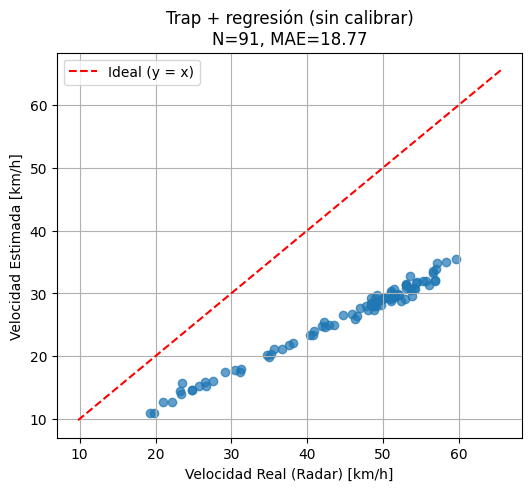

In [11]:
# Calculamos velocidades con trap + regresión usando el FPS del video
df_trap_reg = compute_speed_trap_regression(
    df_tracks=df_tracks,
    lane_configs=lane_configs,
    fps=fps_video,
    margin_px=10,
    min_frames=5,
    use_axis="y",
)

# Juntamos con las velocidades reales del radar
df_trap_reg_eval = df_trap_reg.merge(
    df_gt[["vehicle_id", "gt_speed"]],
    on="vehicle_id",
    how="inner",
)

print("Vehículos con predicción y radar:", df_trap_reg_eval.shape[0])

# Métricas sin calibrar, para tener referencia
metrics_trap_reg_raw = evaluate_predictions(
    df_trap_reg_eval,
    pred_col="speed_trap_reg",
    gt_col="gt_speed",
)

scatter_real_vs_est(
    df_trap_reg_eval,
    pred_col="speed_trap_reg",
    gt_col="gt_speed",
    title="Trap + regresión (sin calibrar)",
    subtitle=f"N={df_trap_reg_eval.shape[0]}, MAE={metrics_trap_reg_raw['MAE']:.2f}",
)


In [12]:
from numpy.random import default_rng

def split_calib_test(df_eval, calib_frac=0.3, seed=0):
    """
    Separa los vehicle_id en calibración y test.

    Parámetros:
      - df_eval: DataFrame con 'vehicle_id'.
      - calib_frac: fracción aproximada para calibración.
      - seed: semilla aleatoria.

    Returns:
      - calib_ids: set de IDs de calibración.
      - test_ids: set de IDs de test.
    """
    ids = df_eval["vehicle_id"].dropna().unique()
    rng = default_rng(seed)
    rng.shuffle(ids)

    n_calib = max(5, int(len(ids) * calib_frac))
    calib_ids = set(ids[:n_calib])
    test_ids  = set(ids[n_calib:])

    print(f"Total vehículos con radar: {len(ids)}")
    print(f"  Calibración: {len(calib_ids)}")
    print(f"  Test:        {len(test_ids)}")
    return calib_ids, test_ids

calib_ids, test_ids = split_calib_test(df_trap_reg_eval, calib_frac=0.3, seed=0)


Total vehículos con radar: 91
  Calibración: 27
  Test:        64


In [13]:
def calibrate_lane_scales(df_eval, calib_ids,
                          pred_col="speed_trap_reg",
                          gt_col="gt_speed",
                          lane_col="lane",
                          min_samples=4):
    """
    Ajusta un factor de escala K_lane por carril usando SOLO vehículos de calibración.

    Se asume gt ≈ K_lane * pred y se calcula K_lane = sum(x*y)/sum(x^2)
    (regresión sin término independiente) por carril.

    Parámetros:
      - df_eval: DataFrame con predicciones y gt.
      - calib_ids: set de vehicle_id para calibración.
      - pred_col, gt_col, lane_col: nombres de columnas.
      - min_samples: mínimo de vehículos por carril.

    Returns:
      - lane_scales: dict {lane -> K_lane}
      - df_calib: DataFrame de calibración con columna 'pred_calib'.
    """
    df_calib = df_eval[df_eval["vehicle_id"].isin(calib_ids)].copy()

    lane_scales = {}
    for lane, df_lane in df_calib.groupby(lane_col):
        x = df_lane[pred_col].to_numpy()
        y = df_lane[gt_col].to_numpy()
        mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[mask]
        y = y[mask]

        if len(x) < min_samples:
            print(f"Lane {lane}: pocos datos ({len(x)}), K_lane = 1.0 (sin calibrar).")
            lane_scales[lane] = 1.0
            continue

        K = np.sum(x * y) / np.sum(x * x)
        lane_scales[lane] = K
        print(f"Lane {lane}: n={len(x)}, K_lane={K:.4f}")

    df_calib["pred_calib"] = df_calib.apply(
        lambda r: r[pred_col] * lane_scales.get(r[lane_col], 1.0),
        axis=1
    )

    return lane_scales, df_calib

lane_scales, df_calib_scaled = calibrate_lane_scales(
    df_trap_reg_eval,
    calib_ids,
    pred_col="speed_trap_reg",
    gt_col="gt_speed",
    lane_col="lane",
    min_samples=4,
)

lane_scales


Lane 1: n=9, K_lane=1.6916
Lane 2: n=9, K_lane=1.7036
Lane 3: n=9, K_lane=1.7407


{1: 1.691643234487755, 2: 1.7036207750842118, 3: 1.7406938100551954}

=== CALIB (solo para ver que ajusta, NO reportar esto como resultado final) ===
MAE  = 0.74 km/h
RMSE = 0.97 km/h
MAPE = 1.6 %
R²   = 0.992

=== TEST (estos son los números que van al informe) ===
MAE  = 0.77 km/h
RMSE = 1.06 km/h
MAPE = 1.8 %
R²   = 0.991


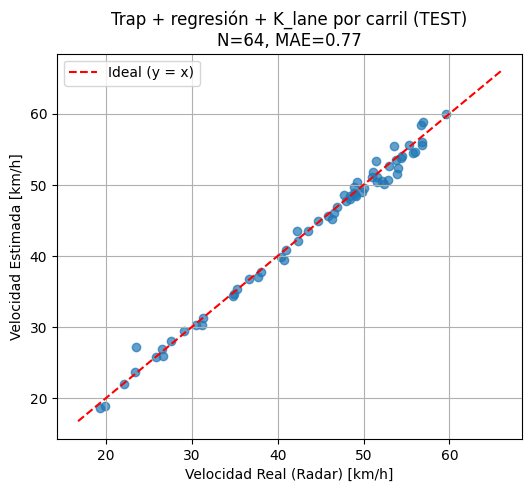

In [14]:
# Aplicamos K_lane a TODAS las predicciones (no usamos gt de cada auto)
df_trap_reg_eval["speed_trap_reg_lane_cal"] = df_trap_reg_eval.apply(
    lambda r: r["speed_trap_reg"] * lane_scales.get(r["lane"], 1.0),
    axis=1
)

# Armamos dataframes de calib y test
df_trap_reg_eval_calib = df_trap_reg_eval[df_trap_reg_eval["vehicle_id"].isin(calib_ids)]
df_trap_reg_eval_test  = df_trap_reg_eval[df_trap_reg_eval["vehicle_id"].isin(test_ids)]

print("=== CALIB (solo para ver que ajusta, NO reportar esto como resultado final) ===")
metrics_calib = evaluate_predictions(
    df_trap_reg_eval_calib,
    pred_col="speed_trap_reg_lane_cal",
    gt_col="gt_speed",
)

print("\n=== TEST (estos son los números que van al informe) ===")
metrics_test = evaluate_predictions(
    df_trap_reg_eval_test,
    pred_col="speed_trap_reg_lane_cal",
    gt_col="gt_speed",
)

scatter_real_vs_est(
    df_trap_reg_eval_test,
    pred_col="speed_trap_reg_lane_cal",
    gt_col="gt_speed",
    title="Trap + regresión + K_lane por carril (TEST)",
    subtitle=f"N={df_trap_reg_eval_test.shape[0]}, MAE={metrics_test['MAE']:.2f}",
)


In [37]:
# ==========================
# CONFIG VIDEO + MODELO LP
# ==========================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract
from ultralytics import YOLO

# Igual que en speed.ipynb
VIDEO_PATH = "video01/video.mp4"   # ajustá si lo tenés en otro lado
LP_MODEL_PATH = "license_plate_detector.pt"  # pesos del repo YOLOv8-ALPR
SPEED_LIMIT = 50.0  # km/h

print("VIDEO_PATH:", VIDEO_PATH, "| existe:", os.path.exists(VIDEO_PATH))
print("LP_MODEL_PATH:", LP_MODEL_PATH, "| existe:", os.path.exists(LP_MODEL_PATH))

# Si querés, seteá el binario de Tesseract en Windows
# pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Cargar modelo de patentes
lp_model = YOLO(LP_MODEL_PATH)
print("✅ Modelo de matrículas cargado.")


VIDEO_PATH: video01/video.mp4 | existe: True
LP_MODEL_PATH: license_plate_detector.pt | existe: True
✅ Modelo de matrículas cargado.


In [38]:
# ==============================
# HELPERS DE VIDEO Y GEOMETRÍA
# ==============================

def load_frame(frame_idx, video_path=VIDEO_PATH):
    """
    Devuelve el frame 'frame_idx' del video como imagen BGR.

    Parámetros:
      - frame_idx: número de frame (0-based).
      - video_path: ruta al video (string).

    Returns:
      - frame BGR (np.ndarray).

    Lanza error claro si no se puede abrir o leer.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        raise FileNotFoundError(
            f"No se pudo abrir el video: {video_path}. "
            "Revisá la ruta y el directorio de trabajo (mismo que en speed.ipynb)."
        )

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()

    if not ok or frame is None:
        raise RuntimeError(f"No se pudo leer el frame {frame_idx} del video {video_path}.")

    return frame


def choose_frame_in_trap(df_v, cfg_lane):
    """
    Elige un frame representativo del vehículo dentro de la speed trap.

    Usa el frame cuyo py está más cerca del centro de la trap.
    Si no hay ningún frame en la trap, devuelve None.
    """
    y_min = cfg_lane["trap_limits"]["y_min"]
    y_max = cfg_lane["trap_limits"]["y_max"]
    y_c   = 0.5 * (y_min + y_max)

    df_zone = df_v[(df_v["py"] >= y_min) & (df_v["py"] <= y_max)]
    if df_zone.empty:
        return None

    idx = (df_zone["py"] - y_c).abs().idxmin()
    return df_zone.loc[idx]


def box_iou(boxA, boxB):
    """
    IoU entre dos cajas [x1,y1,x2,y2].

    Sirve para matchear la placa detectada con el vehículo correcto.
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH

    areaA = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    areaB = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])

    denom = areaA + areaB - interArea + 1e-9
    return interArea / denom


In [39]:
# =========================================
# DETECCIÓN DE PATENTE + OCR CON TESSERACT
# =========================================

def detect_plate_yolo_fullframe(frame_bgr, car_bbox, model, conf_th=0.2, min_iou=0.05):
    """
    Corre YOLO de matrículas sobre el frame completo y se queda con
    la detección que mejor se solapa con el bbox del auto.

    Parámetros:
      - frame_bgr: frame completo (BGR).
      - car_bbox: (x1,y1,x2,y2) del vehículo.
      - model: modelo YOLO de matrículas.
      - conf_th: confianza mínima para aceptar una detección.
      - min_iou: IoU mínima con el auto.

    Returns:
      - crop_lp: recorte BGR de la matrícula o None.
      - plate_box: bbox [x1,y1,x2,y2] en coordenadas del frame o None.
    """
    results = model.predict(frame_bgr, verbose=False)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None, None

    car_box = list(map(int, car_bbox))
    best_box = None
    best_score = 0.0

    for b in boxes:
        conf = float(b.conf)
        if conf < conf_th:
            continue
        bx1, by1, bx2, by2 = b.xyxy[0].tolist()
        det_box = [int(bx1), int(by1), int(bx2), int(by2)]
        iou = box_iou(car_box, det_box)
        if iou < min_iou:
            continue
        # Score combinado de confianza + IoU
        score = conf * (0.5 + 0.5 * iou)
        if score > best_score:
            best_score = score
            best_box = det_box

    if best_box is None:
        return None, None

    x1, y1, x2, y2 = best_box
    H, W = frame_bgr.shape[:2]
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(W, x2); y2 = min(H, y2)
    crop = frame_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return None, None

    return crop, best_box


def ocr_plate(crop_bgr):
    """
    Lee texto de una matrícula usando Tesseract.

    Parámetros:
      - crop_bgr: recorte BGR de la placa.

    Returns:
      - string con letras/números, sin espacios, en mayúsculas.
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return ""

    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 9, 75, 75)
    th = cv2.adaptiveThreshold(gray, 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY,
                               35, 5)

    config = "--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    txt = pytesseract.image_to_string(th, config=config)
    txt = txt.strip().replace(" ", "").upper()
    txt = "".join(ch for ch in txt if ch.isalnum())
    return txt


In [40]:
# =========================================
# DETECCIÓN DE PATENTE + OCR CON TESSERACT
# =========================================

def detect_plate_yolo_fullframe(frame_bgr, car_bbox, model, conf_th=0.2, min_iou=0.05):
    """
    Corre YOLO de matrículas sobre el frame completo y se queda con
    la detección que mejor se solapa con el bbox del auto.

    Parámetros:
      - frame_bgr: frame completo (BGR).
      - car_bbox: (x1,y1,x2,y2) del vehículo.
      - model: modelo YOLO de matrículas.
      - conf_th: confianza mínima para aceptar una detección.
      - min_iou: IoU mínima con el auto.

    Returns:
      - crop_lp: recorte BGR de la matrícula o None.
      - plate_box: bbox [x1,y1,x2,y2] en coordenadas del frame o None.
    """
    results = model.predict(frame_bgr, verbose=False)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None, None

    car_box = list(map(int, car_bbox))
    best_box = None
    best_score = 0.0

    for b in boxes:
        conf = float(b.conf)
        if conf < conf_th:
            continue
        bx1, by1, bx2, by2 = b.xyxy[0].tolist()
        det_box = [int(bx1), int(by1), int(bx2), int(by2)]
        iou = box_iou(car_box, det_box)
        if iou < min_iou:
            continue
        # Score combinado de confianza + IoU
        score = conf * (0.5 + 0.5 * iou)
        if score > best_score:
            best_score = score
            best_box = det_box

    if best_box is None:
        return None, None

    x1, y1, x2, y2 = best_box
    H, W = frame_bgr.shape[:2]
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(W, x2); y2 = min(H, y2)
    crop = frame_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return None, None

    return crop, best_box


def ocr_plate(crop_bgr):
    """
    Lee texto de una matrícula usando Tesseract.

    Parámetros:
      - crop_bgr: recorte BGR de la placa.

    Returns:
      - string con letras/números, sin espacios, en mayúsculas.
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return ""

    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 9, 75, 75)
    th = cv2.adaptiveThreshold(gray, 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY,
                               35, 5)

    config = "--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    txt = pytesseract.image_to_string(th, config=config)
    txt = txt.strip().replace(" ", "").upper()
    txt = "".join(ch for ch in txt if ch.isalnum())
    return txt


In [43]:
# ============================================
# PIPELINE: VELOCIDAD + MATRÍCULA (YOLO + OCR)
# ============================================

import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"



def build_speed_plate_table_yolo(df_tracks, df_speed_eval, lane_configs,
                                 lp_model,
                                 speed_col="speed_trap_reg_lane_cal",
                                 speed_limit=SPEED_LIMIT):
    """
    Para cada vehículo con velocidad estimada:
      - Elige un frame (trap si se puede, sino centro del track).
      - Corre YOLO de matrículas sobre el frame completo.
      - Matchea la placa con el auto por IoU.
      - Hace OCR sobre el recorte de la matrícula.

    Devuelve un DataFrame con:
      vehicle_id, lane, speed_est, gt_speed,
      is_speeding_pred, is_speeding_gt,
      plate_text, plate_bbox
    """
    rows = []

    df_tracks_v = df_tracks.dropna(subset=["vehicle_id"]).copy()
    df_tracks_v["vehicle_id"] = df_tracks_v["vehicle_id"].astype(int)

    n_no_frame = 0
    n_no_det = 0
    n_det = 0
    n_ocr_nonempty = 0

    for _, row_s in df_speed_eval.iterrows():
        vid = int(row_s["vehicle_id"])
        lane = row_s.get("lane", None)
        speed_est = float(row_s[speed_col])
        gt = float(row_s["gt_speed"])

        df_v = df_tracks_v[df_tracks_v["vehicle_id"] == vid]

        def append_row(plate_text="", plate_bbox=None):
            rows.append({
                "vehicle_id": vid,
                "lane": lane,
                "speed_est": speed_est,
                "gt_speed": gt,
                "is_speeding_pred": speed_est > speed_limit,
                "is_speeding_gt": gt > speed_limit,
                "plate_text": plate_text,
                "plate_bbox": plate_bbox,
            })

        if df_v.empty or lane not in lane_configs:
            append_row()
            continue

        cfg_lane = lane_configs[lane]
        pick = choose_frame_in_trap(df_v, cfg_lane)
        if pick is None:
            pick = df_v.sort_values("frame").iloc[len(df_v) // 2]

        frame_idx = int(pick["frame"])

        try:
            frame = load_frame(frame_idx)
        except Exception as e:
            n_no_frame += 1
            append_row()
            continue

        car_bbox = (pick["x1"], pick["y1"], pick["x2"], pick["y2"])

        crop_lp, plate_bbox = detect_plate_yolo_fullframe(
            frame, car_bbox, lp_model,
            conf_th=0.15,   # podés subir/bajar esto para más/menos detecciones
            min_iou=0.02    # muy bajo para no perder detecciones cerca
        )

        if crop_lp is None:
            n_no_det += 1
            append_row()
            continue

        n_det += 1
        plate_text = ocr_plate(crop_lp)
        if plate_text:
            n_ocr_nonempty += 1

        append_row(plate_text=plate_text, plate_bbox=plate_bbox)

    df_sp = pd.DataFrame(rows)
    print("Vehículos procesados           :", df_sp.shape[0])
    print("Frames no leídos del video     :", n_no_frame)
    print("Sin detección de matrícula YOLO:", n_no_det)
    print("Con detección de matrícula YOLO:", n_det)
    print("Con texto OCR no vacío         :", n_ocr_nonempty)

    display(df_sp.head())
    return df_sp


df_speed_plate = build_speed_plate_table_yolo(
    df_tracks=df_tracks,
    df_speed_eval=df_trap_reg_eval,
    lane_configs=lane_configs,
    lp_model=lp_model,
    speed_col="speed_trap_reg_lane_cal",
    speed_limit=SPEED_LIMIT,
)


Vehículos procesados           : 91
Frames no leídos del video     : 55
Sin detección de matrícula YOLO: 7
Con detección de matrícula YOLO: 29
Con texto OCR no vacío         : 16


,vehicle_id,lane,speed_est,gt_speed,is_speeding_pred,is_speeding_gt,plate_text,plate_bbox
0,1,3.0,58.370781,56.65,True,True,,"[1189, 67, 1263, 109]"
1,2,3.0,53.508414,53.74,True,True,,None
2,3,2.0,50.582505,52.13,True,True,,None
3,4,3.0,48.592199,49.06,False,False,,None
4,5,2.0,50.174985,50.51,True,True,,None


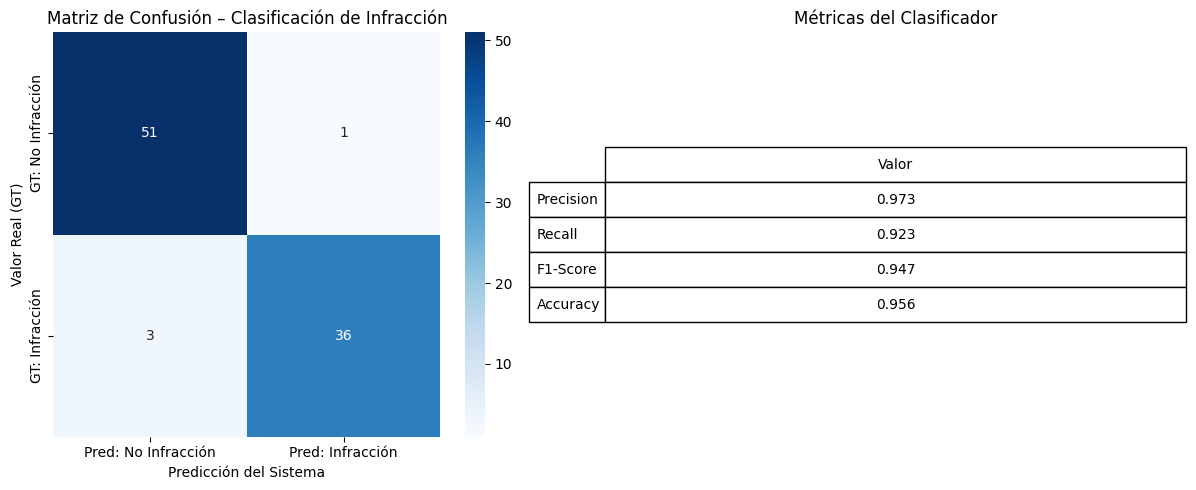

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ============================
#  Computar métricas
# ============================

y_true = df_speed_plate["is_speeding_gt"].astype(bool).to_numpy()
y_pred = df_speed_plate["is_speeding_pred"].astype(bool).to_numpy()

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[False, True]).ravel()

precision  = precision_score(y_true, y_pred, zero_division=0)
recall     = recall_score(y_true, y_pred, zero_division=0)
f1         = f1_score(y_true, y_pred, zero_division=0)
accuracy   = accuracy_score(y_true, y_pred)

# Para la tabla
metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "Accuracy"],
    "Value":  [precision,   recall,   f1,         accuracy]
})

# ============================
#  FIGURA UNIFICADA
# ============================

fig = plt.figure(figsize=(12, 5))

# ---- Subplot 1: Confusion Matrix ----
ax1 = fig.add_subplot(1, 2, 1)

cm_df = pd.DataFrame([[tn, fp],
                      [fn, tp]],
                     index=["GT: No Infracción", "GT: Infracción"],
                     columns=["Pred: No Infracción", "Pred: Infracción"])

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax1)
ax1.set_title("Matriz de Confusión – Clasificación de Infracción")
ax1.set_ylabel("Valor Real (GT)")
ax1.set_xlabel("Predicción del Sistema")

# ---- Subplot 2: Tabla de métricas ----
ax2 = fig.add_subplot(1, 2, 2)
ax2.axis("off")

table = ax2.table(
    cellText=[[f"{v:.3f}" if isinstance(v, float) else v] for v in metrics_df["Value"]],
    rowLabels=metrics_df["Metric"],
    colLabels=["Valor"],
    cellLoc="center",
    loc="center"
)
table.scale(1.2, 2.0)
ax2.set_title("Métricas del Clasificador")

plt.tight_layout()
plt.show()
